# Phase 2: China Uncertainty & Markets - Exploratory Analysis

This notebook explores relationships between China Economic Policy Uncertainty (CNEPU) and CSI 300 index volatility.

**Objective**: Identify patterns, correlations, and lead-lag relationships to inform modeling decisions.

**Input**: `data/processed/cepu_csi300_merged.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 120

DATA_PROCESSED = Path('../../../../data/processed')

print('Setup complete ✓')

Setup complete ✓


## 1. Load Processed Data

In [2]:
# Load merged dataset
df = pd.read_csv(DATA_PROCESSED / 'cepu_csi300_merged.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Fill derived columns if missing
if df['CNEPU_MA12'].isna().all() or df['CNEPU_MA12'].isna().sum() > len(df) * 0.5:
    df['CNEPU_MA12'] = df['CNEPU'].rolling(12, min_periods=12).mean()
    print('CNEPU_MA12 recalculated.')

if df['CNEPU_Std12'].isna().all() or df['CNEPU_Std12'].isna().sum() > len(df) * 0.5:
    df['CNEPU_Std12'] = df['CNEPU'].rolling(12, min_periods=12).std()
    print('CNEPU_Std12 recalculated.')

if 'CSI_Vol3m' not in df.columns or df['CSI_Vol3m'].isna().sum() > len(df) * 0.5:
    df['CSI_Vol3m'] = df['CSI_Vol'].rolling(3, min_periods=3).mean()
    print('CSI_Vol3m recalculated.')

if 'CSI_Vol6m' not in df.columns or df['CSI_Vol6m'].isna().sum() > len(df) * 0.5:
    df['CSI_Vol6m'] = df['CSI_Vol'].rolling(6, min_periods=6).mean()
    print('CSI_Vol6m recalculated.')

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns: {list(df.columns)}")

display(df.head())
print("\nLast rows:")
display(df.tail())

Dataset shape: (247, 17)
Date range: 2005-01-01 00:00:00 to 2025-07-01 00:00:00

Columns: ['Date', 'year', 'month', 'CNEPU', 'ΔCNEPU', 'CNEPU_MA12', 'CNEPU_Std12', 'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First', 'CSI_High_Max', 'CSI_Low_Min', 'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m', 'CSI_Trading_Days']


,Date,year,month,CNEPU,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Trading_Days
0,2005-01-01,2005,1,48.805328,NaN,NaN,NaN,982.409000,954.88,994.77,1006.46,943.44,NaN,0.011958,NaN,NaN,20
1,2005-02-01,2005,2,39.653267,-9.152061,NaN,NaN,1020.900000,1039.99,953.33,1059.48,952.74,0.085381,0.018203,NaN,NaN,13
2,2005-03-01,2005,3,41.163791,1.510524,NaN,NaN,996.991739,942.20,1039.35,1054.64,928.34,-0.098749,0.010387,NaN,NaN,23
3,2005-04-01,2005,4,79.471275,38.307484,NaN,NaN,963.126667,932.39,941.43,1008.74,914.83,-0.010466,0.015607,0.092091,NaN,21
4,2005-05-01,2005,5,23.716429,-55.754846,NaN,NaN,877.821765,855.95,934.65,937.39,842.10,-0.085539,0.010562,0.047617,NaN,17



Last rows:


,Date,year,month,CNEPU,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Trading_Days
242,2025-03-01,2025,3,426.836802,185.236802,246.597160,81.465111,3938.946190,3887.31,3899.70,4025.30,3855.73,-0.000705,0.008033,0.024840,0.020951,21
243,2025-04-01,2025,4,524.835928,97.999126,276.438451,110.105690,3768.497619,3770.57,3892.78,3905.26,3514.12,-0.030491,0.017223,0.024887,0.020556,21
244,2025-05-01,2025,5,494.110628,-30.725301,300.424300,123.917520,3873.058421,3840.23,3794.38,3960.52,3782.78,0.018306,0.006593,0.024596,0.022385,19
245,2025-06-01,2025,6,342.742158,-151.368470,318.628191,111.070791,3885.438000,3936.08,3833.46,3969.26,3827.08,0.024653,0.005812,0.030173,0.025124,20
246,2025-07-01,2025,7,345.484294,2.742136,324.205080,110.555057,4040.090952,4152.02,3935.91,4155.68,3924.72,0.053410,0.004068,0.018706,0.027947,21


In [3]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print("Missing values:")
display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

Missing values:


,Missing,Percentage
CNEPU_MA12,11,4.453441
CNEPU_Std12,11,4.453441
CSI_Vol6m,6,2.429150
CSI_Vol3m,3,1.214575
ΔCNEPU,1,0.404858
CSI_Return,1,0.404858


## 2. Descriptive Statistics

### 2.1 Summary Statistics

In [4]:
# Key features for analysis
key_features = ['CNEPU', 'ΔCNEPU', 'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']

print("Summary Statistics:")
display(df[key_features].describe().round(4))

Summary Statistics:


,CNEPU,ΔCNEPU,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m
count,247.0000,246.0000,246.0000,247.0000,244.0000,241.0000
mean,182.0967,1.2060,0.0060,0.0142,0.0608,0.0661
std,123.9373,73.8880,0.0792,0.0073,0.0426,0.0342
min,23.7164,-273.1702,-0.2991,0.0027,0.0035,0.0162
25%,95.0771,-32.4913,-0.0322,0.0092,0.0302,0.0416
50%,133.9478,1.6580,0.0059,0.0120,0.0510,0.0579
75%,248.9792,30.9733,0.0482,0.0177,0.0756,0.0847
max,661.8280,283.9710,0.2463,0.0391,0.2478,0.1671


In [5]:
# Calculate skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df[key_features].skew(),
    'Kurtosis': df[key_features].kurtosis()
})

print("Skewness and Kurtosis:")
display(skew_kurt)

Skewness and Kurtosis:


,Skewness,Kurtosis
CNEPU,1.170277,1.067313
ΔCNEPU,0.262122,2.558202
CSI_Return,-0.369558,2.075844
CSI_Vol,1.333968,1.542568
CSI_Vol3m,1.454344,2.763233
CSI_Vol6m,0.990365,0.493158


### 2.2 Distribution Plots

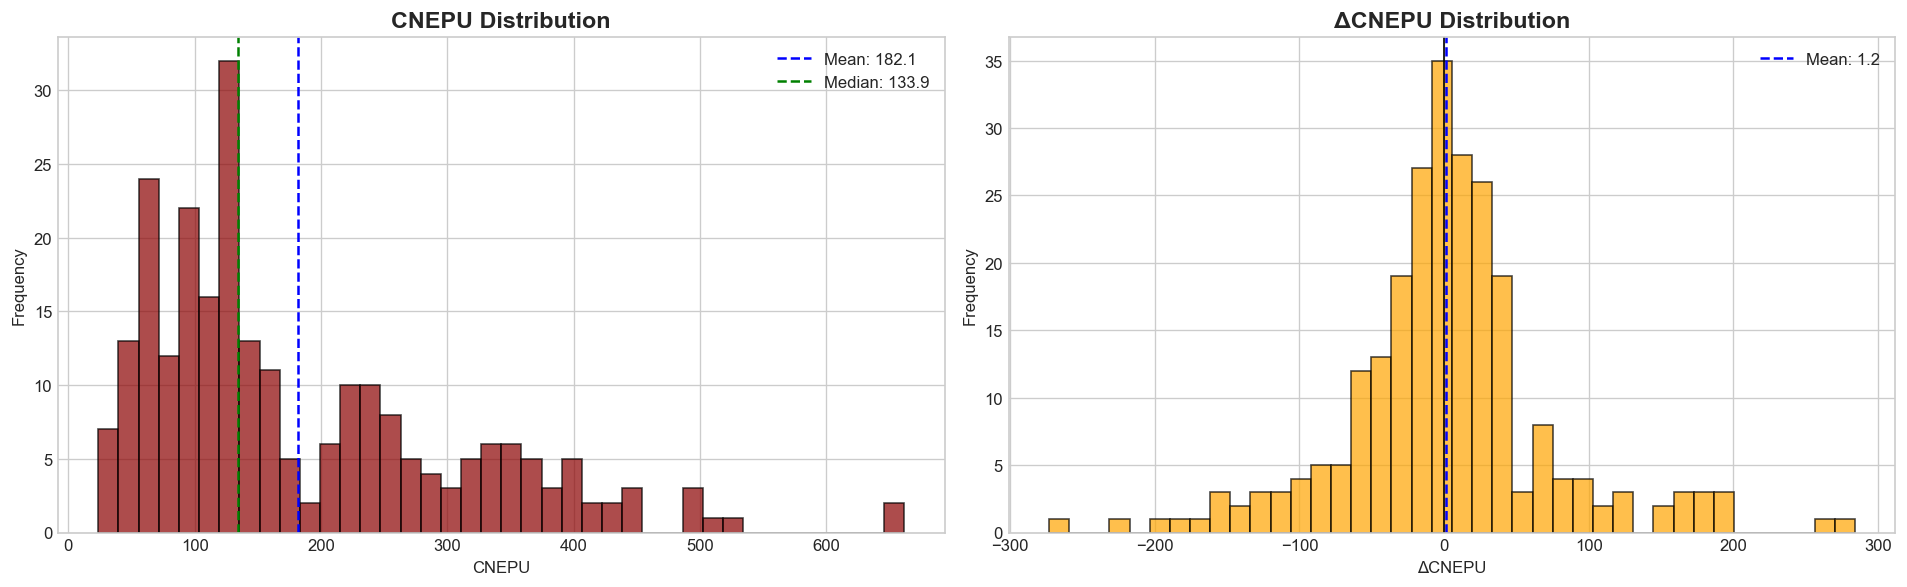

In [6]:
# Distribution plots for CNEPU features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CNEPU
axes[0].hist(df['CNEPU'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='darkred')
axes[0].axvline(df['CNEPU'].mean(), color='blue', linestyle='--', label=f'Mean: {df["CNEPU"].mean():.1f}')
axes[0].axvline(df['CNEPU'].median(), color='green', linestyle='--', label=f'Median: {df["CNEPU"].median():.1f}')
axes[0].set_title('CNEPU Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('CNEPU')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# ΔCNEPU
axes[1].hist(df['ΔCNEPU'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].axvline(df['ΔCNEPU'].mean(), color='blue', linestyle='--', label=f'Mean: {df["ΔCNEPU"].mean():.1f}')
axes[1].set_title('ΔCNEPU Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ΔCNEPU')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

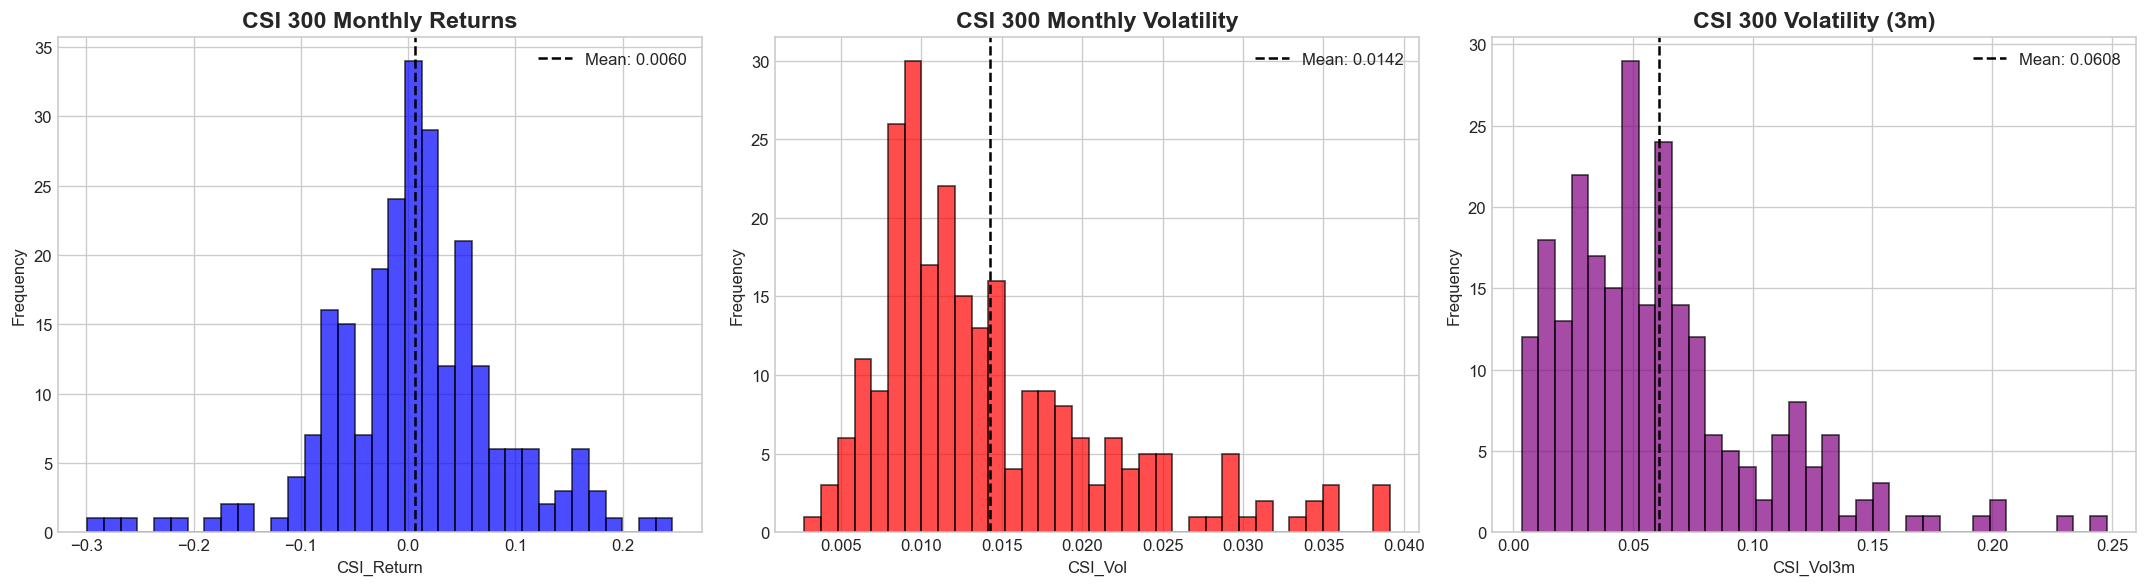

In [7]:
# Distribution plots for market variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vars_plot   = ['CSI_Return', 'CSI_Vol', 'CSI_Vol3m']
colors_plot = ['blue', 'red', 'purple']
titles_plot = ['CSI 300 Monthly Returns', 'CSI 300 Monthly Volatility', 'CSI 300 Volatility (3m)']

for ax, var, color, title in zip(axes, vars_plot, colors_plot, titles_plot):
    data = df[var].dropna()
    ax.hist(data, bins=35, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(data.mean(), color='black', linestyle='--',
               label=f'Mean: {data.mean():.4f}')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

### 2.3 Outlier Detection

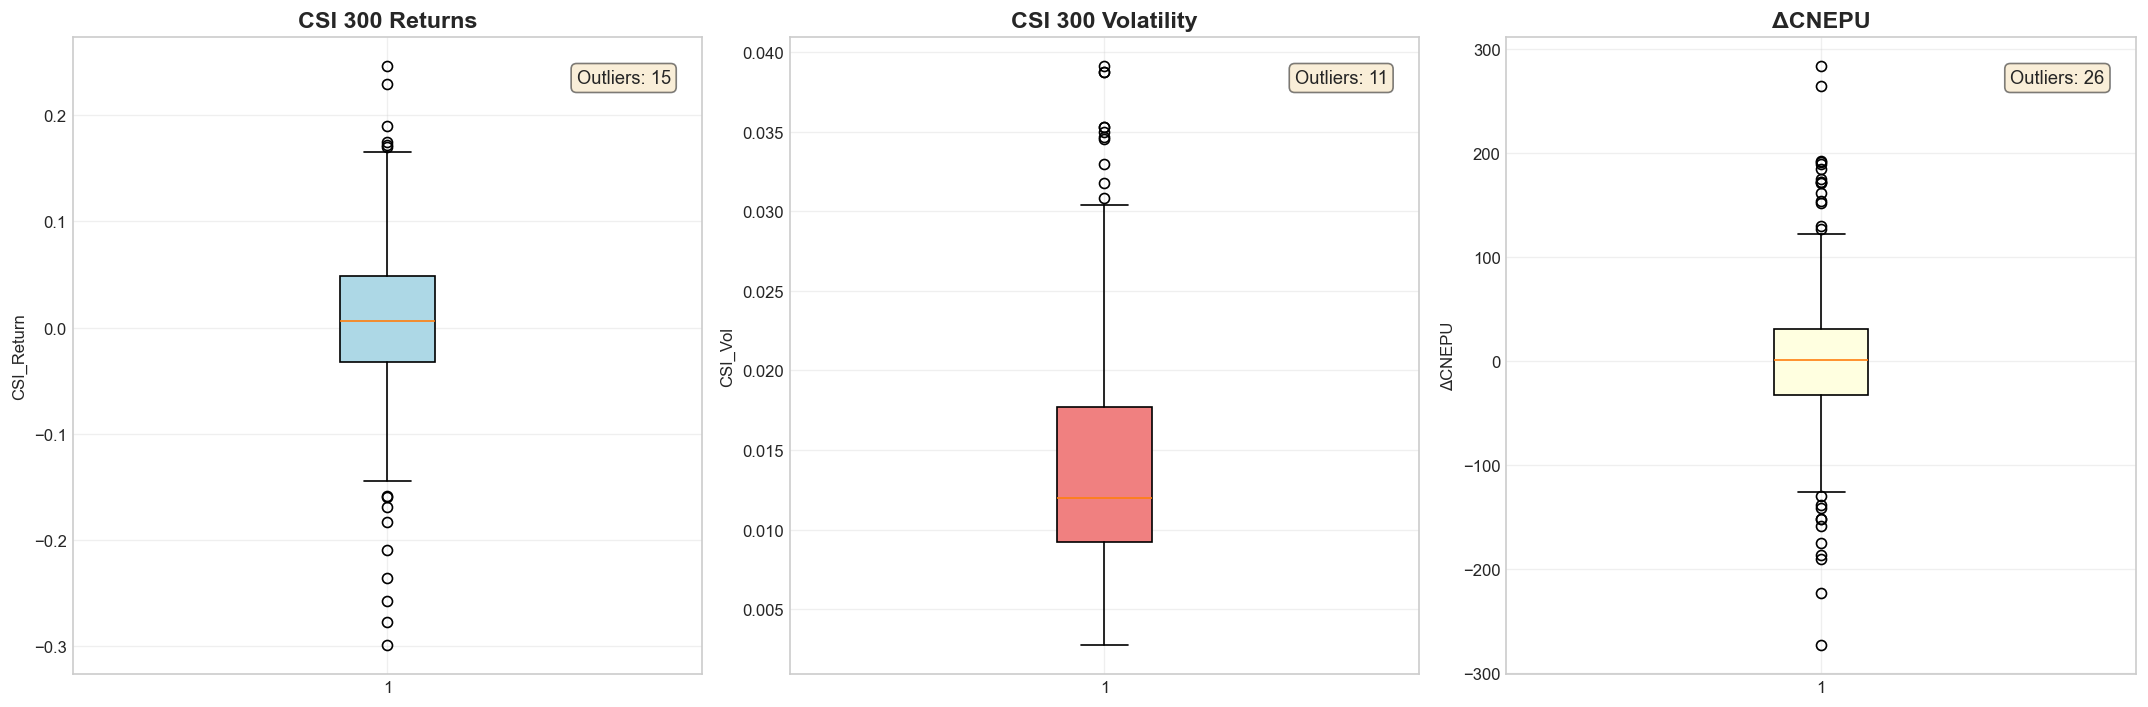

In [8]:
# Boxplots for key variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vars_box   = ['CSI_Return', 'CSI_Vol', 'ΔCNEPU']
colors_box = ['lightblue', 'lightcoral', 'lightyellow']
titles_box = ['CSI 300 Returns', 'CSI 300 Volatility', 'ΔCNEPU']

for ax, var, color, title in zip(axes, vars_box, colors_box, titles_box):
    data = df[var].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

    # Count outliers (IQR method)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    ax.text(0.95, 0.95, f'Outliers: {n_outliers}',
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 3. Temporal Analysis

### 3.1 Time Series: CNEPU and CSI 300 Volatility

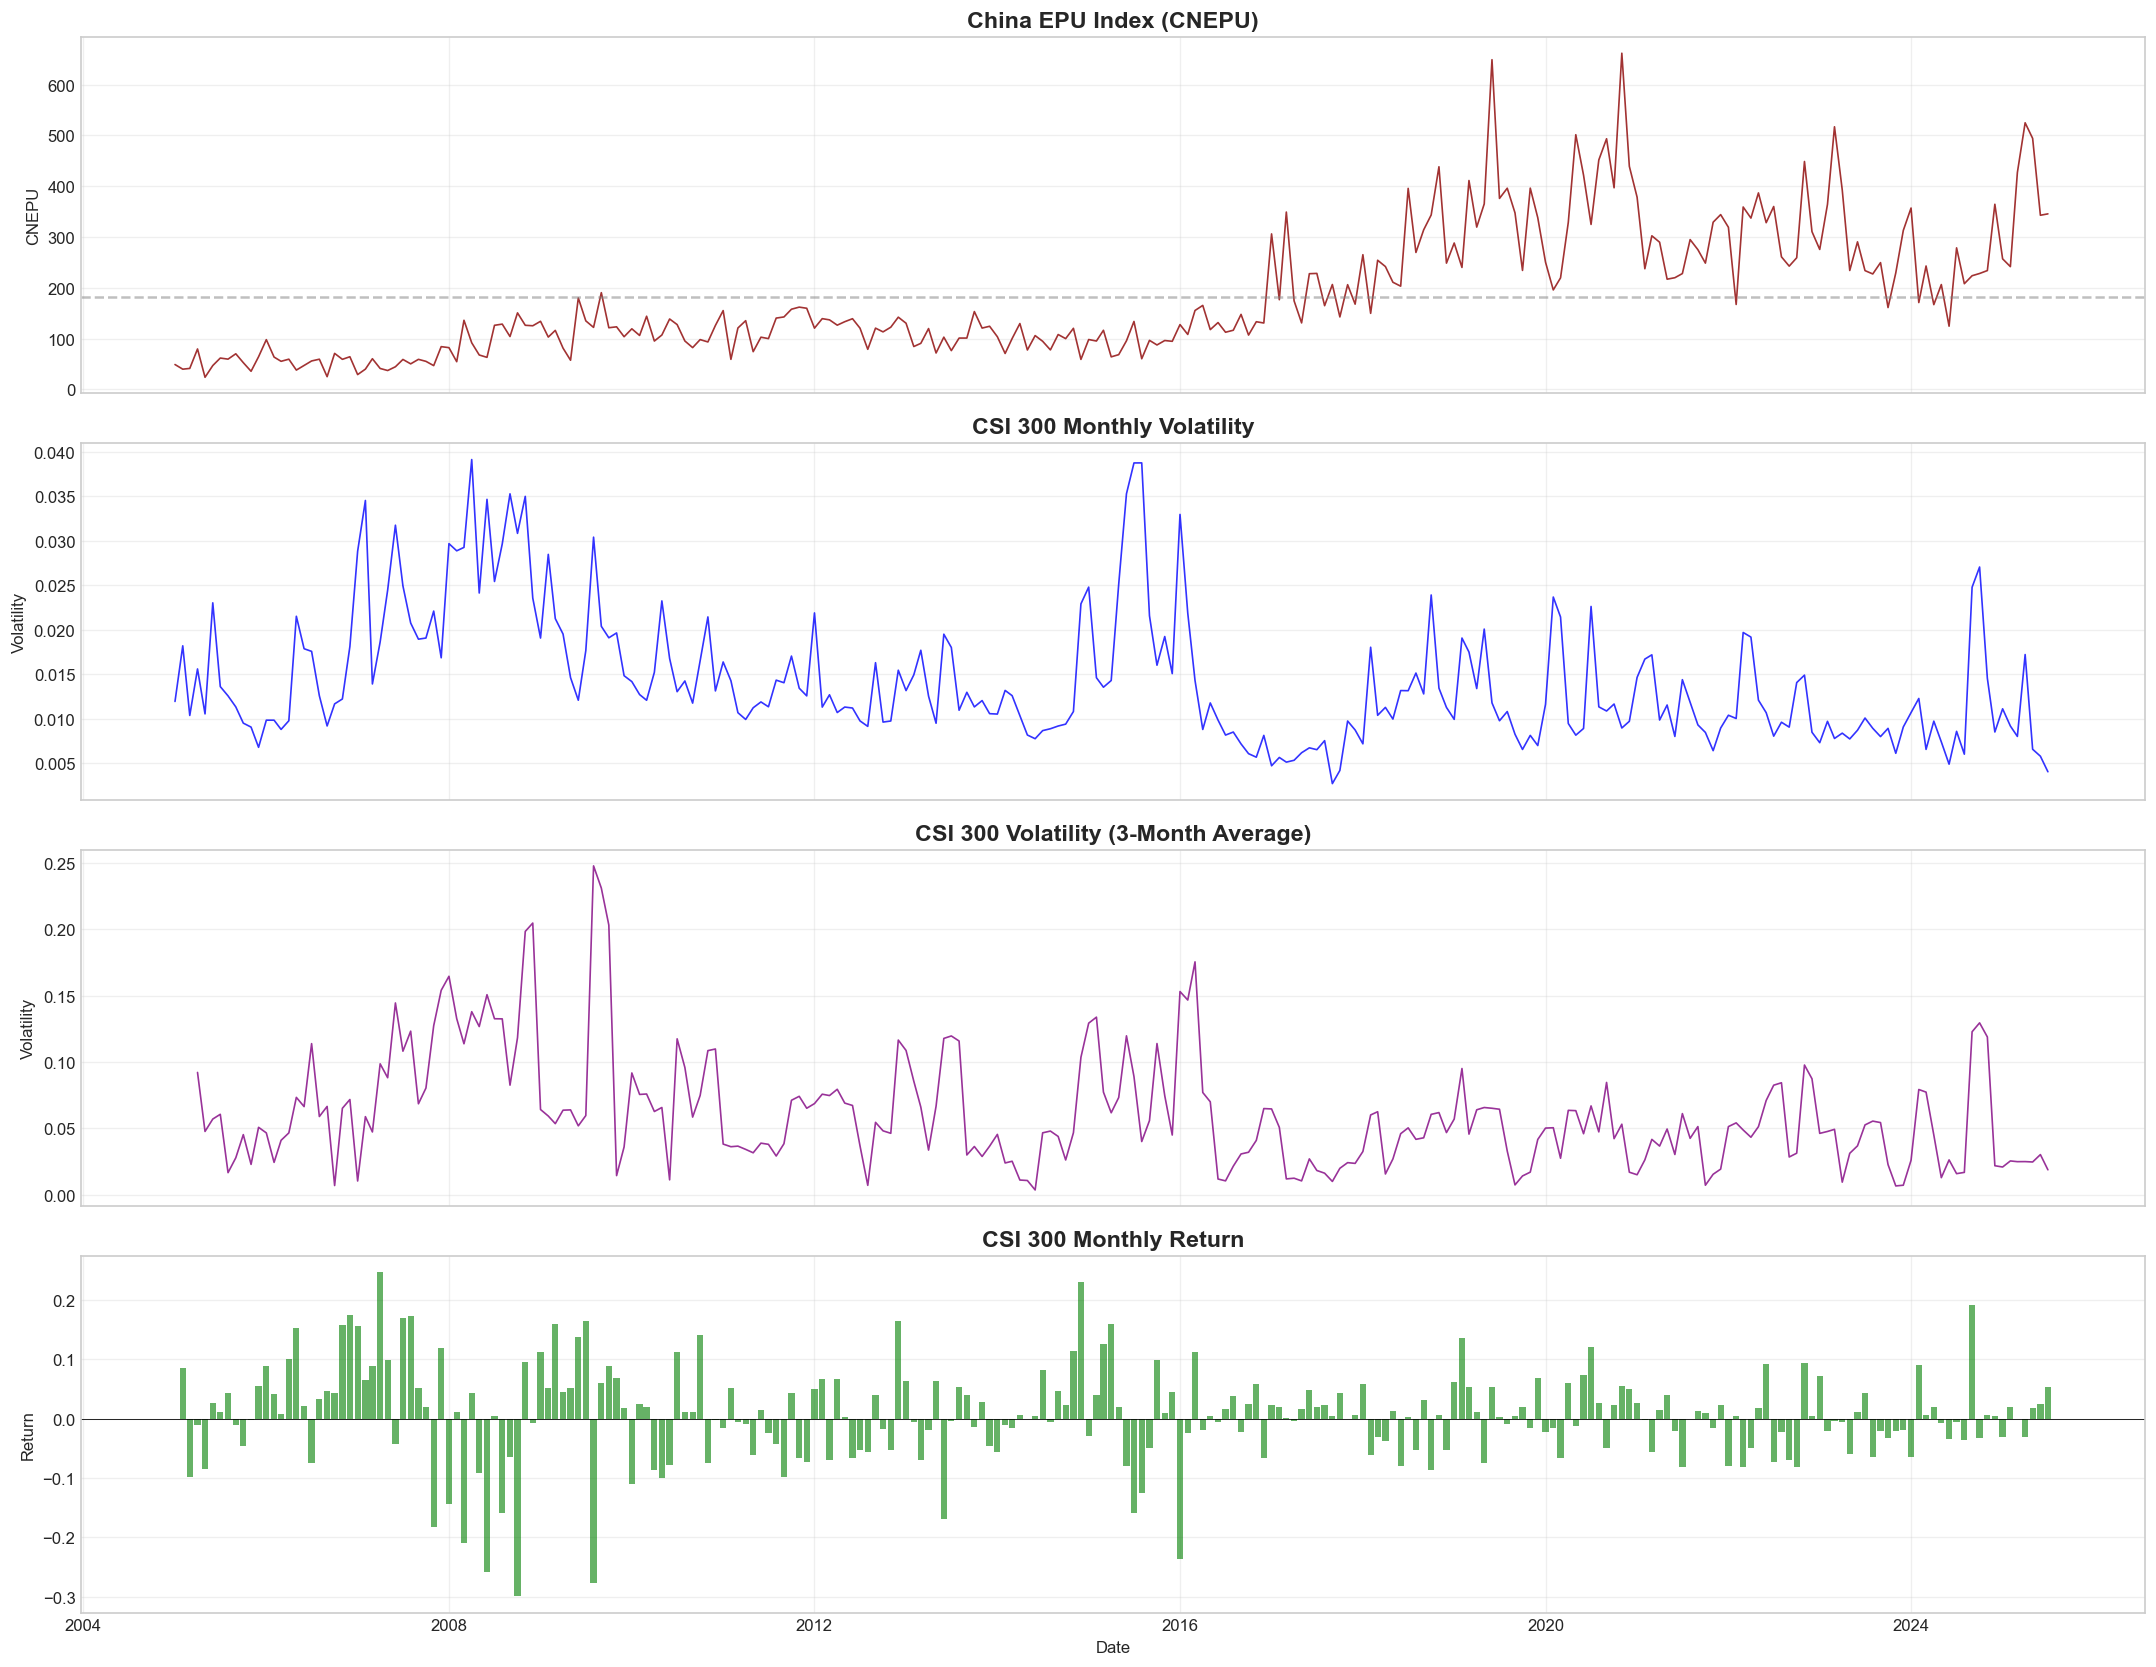

In [9]:
# Plot CNEPU and CSI 300 volatility over time
fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

# CNEPU
axes[0].plot(df['Date'], df['CNEPU'], linewidth=1, color='darkred', alpha=0.8)
axes[0].axhline(df['CNEPU'].mean(), color='grey', linestyle='--', alpha=0.5)
axes[0].set_title('China EPU Index (CNEPU)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CNEPU')
axes[0].grid(True, alpha=0.3)

# CSI_Vol
axes[1].plot(df['Date'], df['CSI_Vol'], linewidth=1, color='blue', alpha=0.8)
axes[1].set_title('CSI 300 Monthly Volatility', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].grid(True, alpha=0.3)

# CSI_Vol3m
axes[2].plot(df['Date'], df['CSI_Vol3m'], linewidth=1, color='purple', alpha=0.8)
axes[2].set_title('CSI 300 Volatility (3-Month Average)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].grid(True, alpha=0.3)

# CSI_Return
axes[3].bar(df['Date'], df['CSI_Return'], width=25, color='green', alpha=0.6)
axes[3].axhline(0, color='black', linewidth=0.5)
axes[3].set_title('CSI 300 Monthly Return', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Return')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Rolling Correlations

In [10]:
# Calculate rolling correlations (12-month and 24-month windows)
window_12 = 12
window_24 = 24

df['CNEPU_Vol_Corr12m'] = df['CNEPU'].rolling(window=window_12).corr(df['CSI_Vol'])
df['CNEPU_Vol_Corr24m'] = df['CNEPU'].rolling(window=window_24).corr(df['CSI_Vol'])
df['CNEPU_Vol3m_Corr12m'] = df['CNEPU'].rolling(window=window_12).corr(df['CSI_Vol3m'])
df['CNEPU_Ret_Corr12m'] = df['CNEPU'].rolling(window=window_12).corr(df['CSI_Return'])

print(f"Rolling correlations computed (12m and 24m windows).")

Rolling correlations computed (12m and 24m windows).


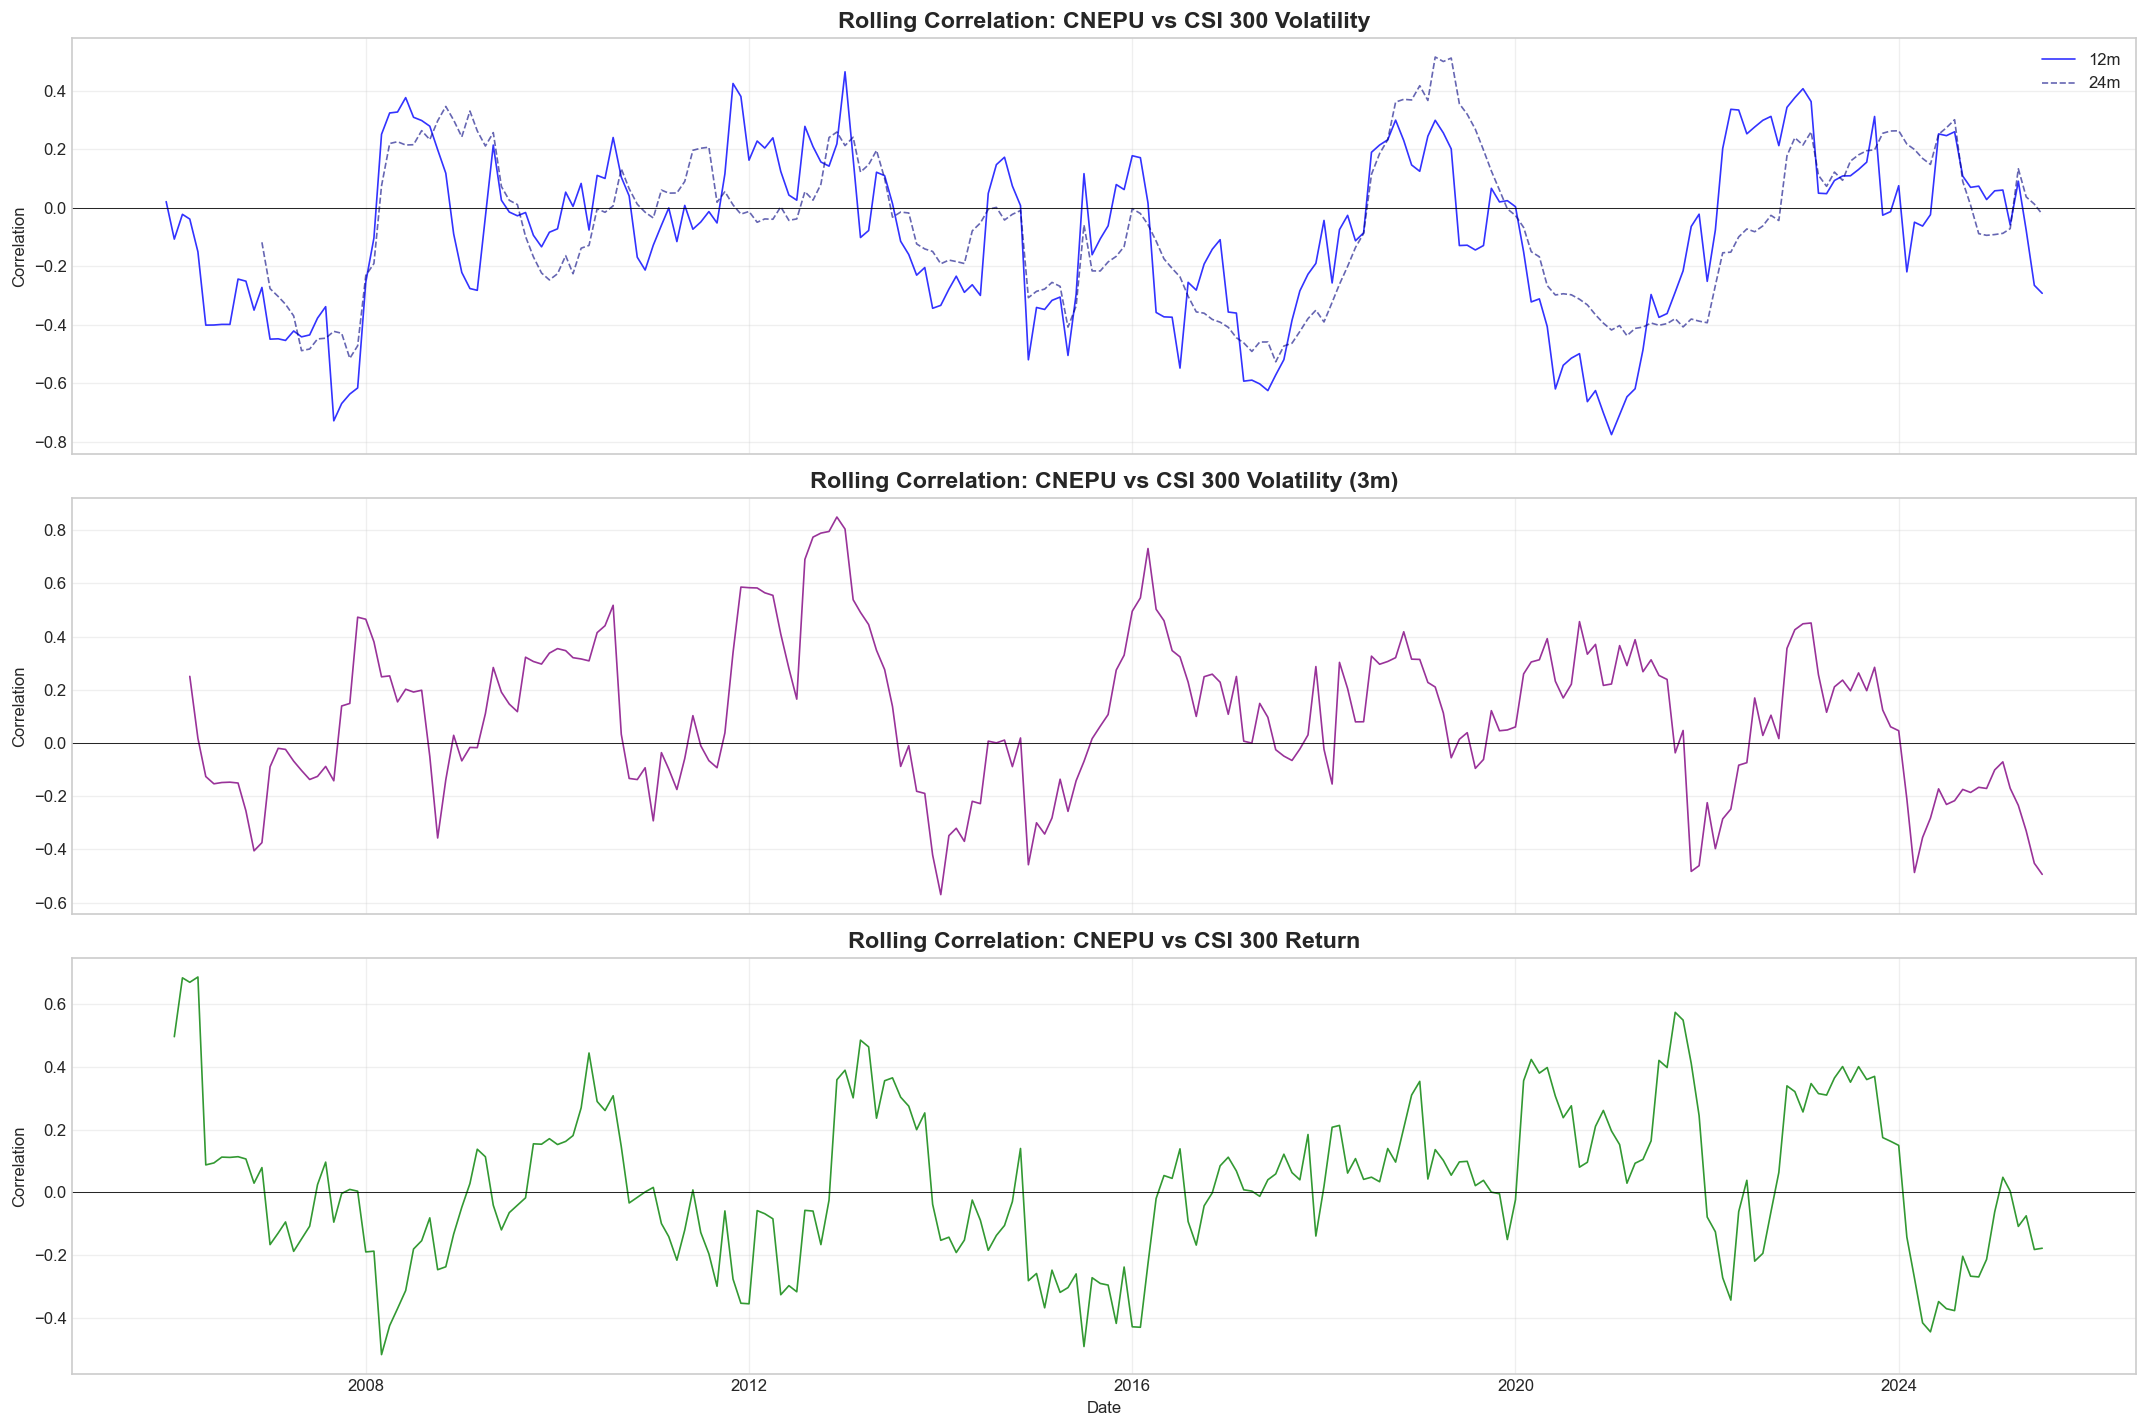

In [11]:
# Plot rolling correlations (12-month window)
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# CNEPU vs CSI_Vol
axes[0].plot(df['Date'], df['CNEPU_Vol_Corr12m'], linewidth=1, color='blue', alpha=0.8, label='12m')
axes[0].plot(df['Date'], df['CNEPU_Vol_Corr24m'], linewidth=1, color='navy', alpha=0.6, linestyle='--', label='24m')
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Rolling Correlation: CNEPU vs CSI 300 Volatility', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Correlation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CNEPU vs CSI_Vol3m
axes[1].plot(df['Date'], df['CNEPU_Vol3m_Corr12m'], linewidth=1, color='purple', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('Rolling Correlation: CNEPU vs CSI 300 Volatility (3m)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Correlation')
axes[1].grid(True, alpha=0.3)

# CNEPU vs CSI_Return
axes[2].plot(df['Date'], df['CNEPU_Ret_Corr12m'], linewidth=1, color='green', alpha=0.8)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_title('Rolling Correlation: CNEPU vs CSI 300 Return', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Correlation')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

### 4.1 Static Correlation Matrix

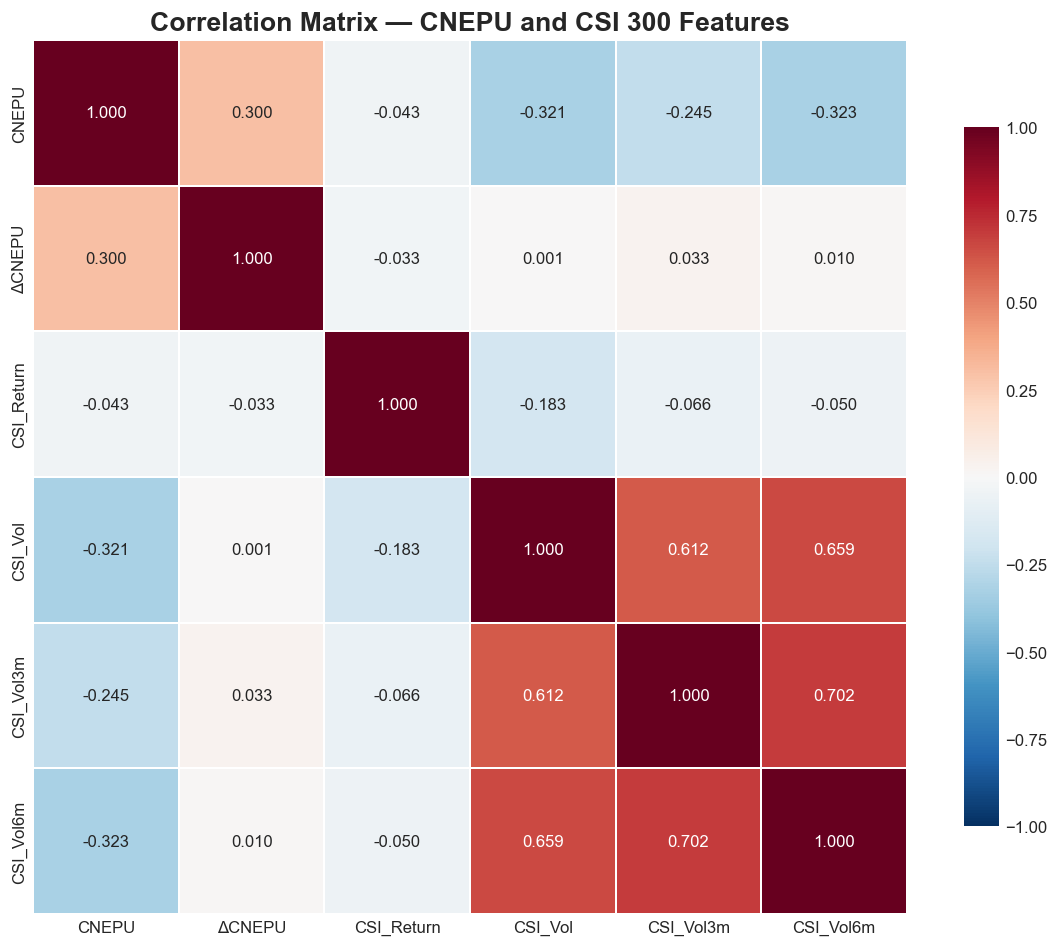


Key Correlations with CNEPU:
CNEPU         1.000000
ΔCNEPU        0.300183
CSI_Return   -0.043391
CSI_Vol3m    -0.244796
CSI_Vol      -0.321417
CSI_Vol6m    -0.323397
Name: CNEPU, dtype: float64

Key Correlations with ΔCNEPU:
ΔCNEPU        1.000000
CNEPU         0.300183
CSI_Vol3m     0.032857
CSI_Vol6m     0.010500
CSI_Vol       0.000979
CSI_Return   -0.032944
Name: ΔCNEPU, dtype: float64


In [12]:
# Correlation matrix for key features
corr_features = ['CNEPU', 'ΔCNEPU', 'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']

corr_matrix = df[corr_features].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — CNEPU and CSI 300 Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key correlations
print("\nKey Correlations with CNEPU:")
cnepu_corrs = corr_matrix['CNEPU'].sort_values(ascending=False)
print(cnepu_corrs)

print("\nKey Correlations with ΔCNEPU:")
dcnepu_corrs = corr_matrix['ΔCNEPU'].sort_values(ascending=False)
print(dcnepu_corrs)

### 4.2 Scatter Plots with Regression

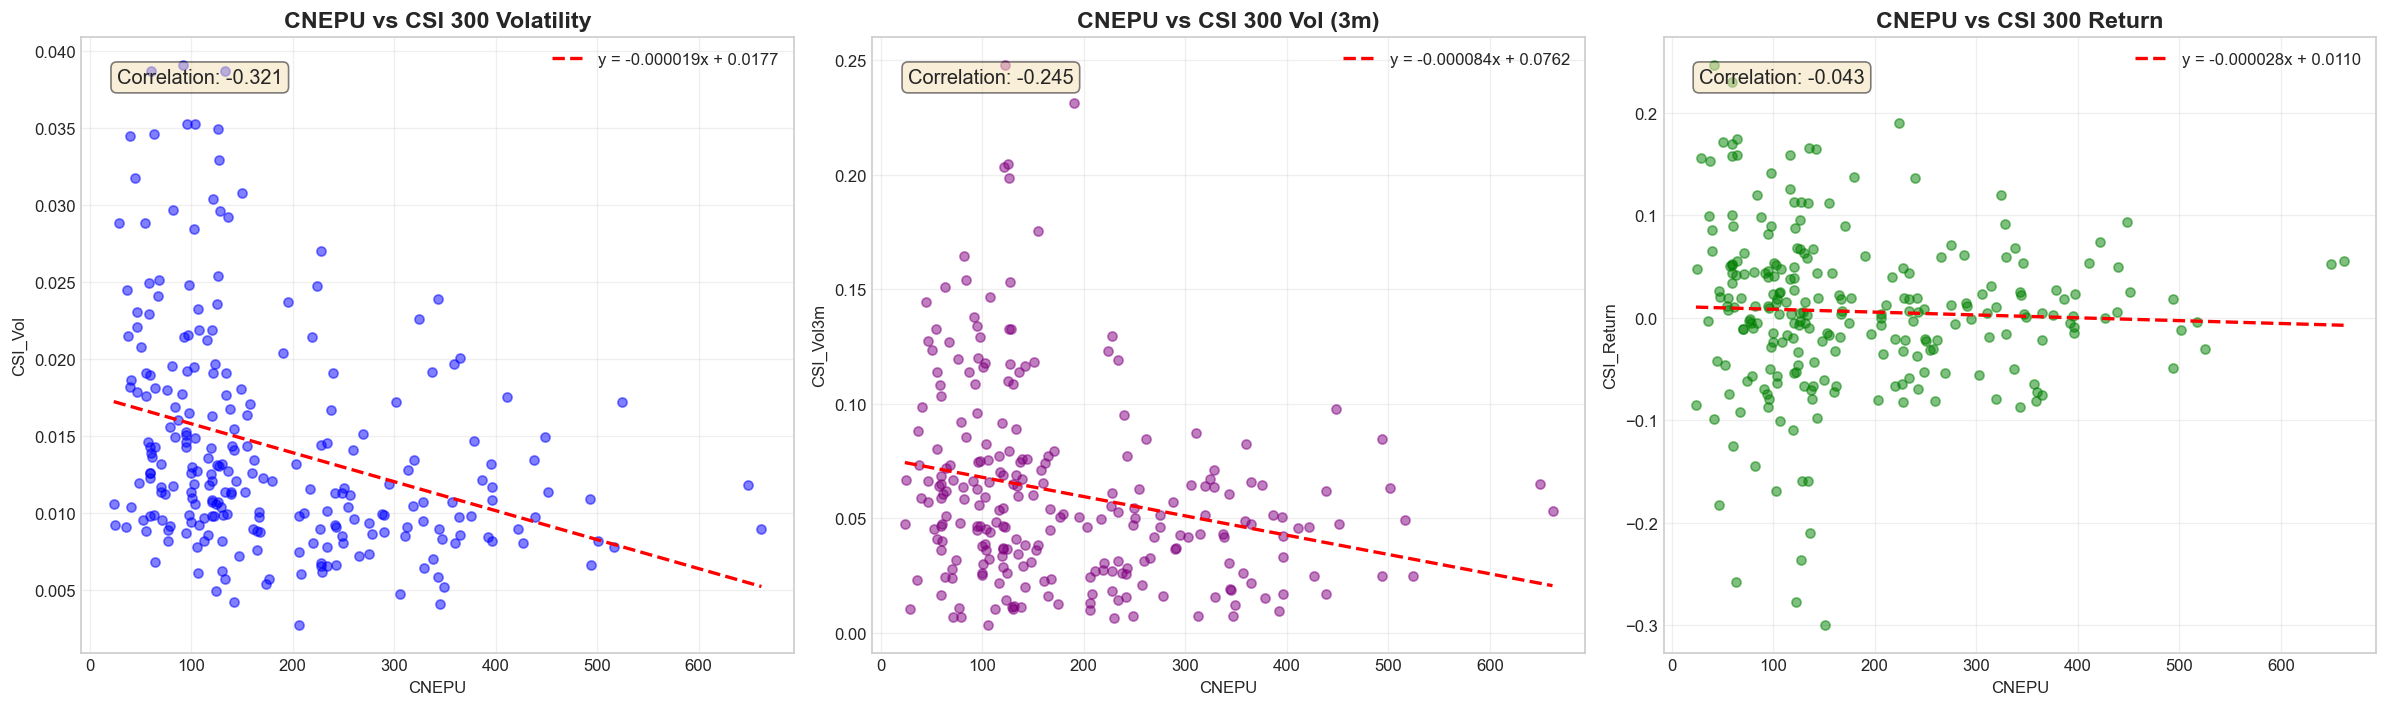

In [13]:
# Scatter plots: CNEPU vs market variables
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

y_vars  = ['CSI_Vol', 'CSI_Vol3m', 'CSI_Return']
colors  = ['blue', 'purple', 'green']
titles  = ['CNEPU vs CSI 300 Volatility', 'CNEPU vs CSI 300 Vol (3m)', 'CNEPU vs CSI 300 Return']

for i, (yvar, color, title) in enumerate(zip(y_vars, colors, titles)):
    data = df[['CNEPU', yvar]].dropna()

    # Scatter plot
    axes[i].scatter(data['CNEPU'], data[yvar], alpha=0.5, s=30, color=color)

    # Regression line
    z = np.polyfit(data['CNEPU'], data[yvar], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['CNEPU'].min(), data['CNEPU'].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2,
                 label=f'y = {z[0]:.6f}x + {z[1]:.4f}')

    # Correlation
    corr = data['CNEPU'].corr(data[yvar])
    axes[i].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                 transform=axes[i].transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('CNEPU')
    axes[i].set_ylabel(yvar)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

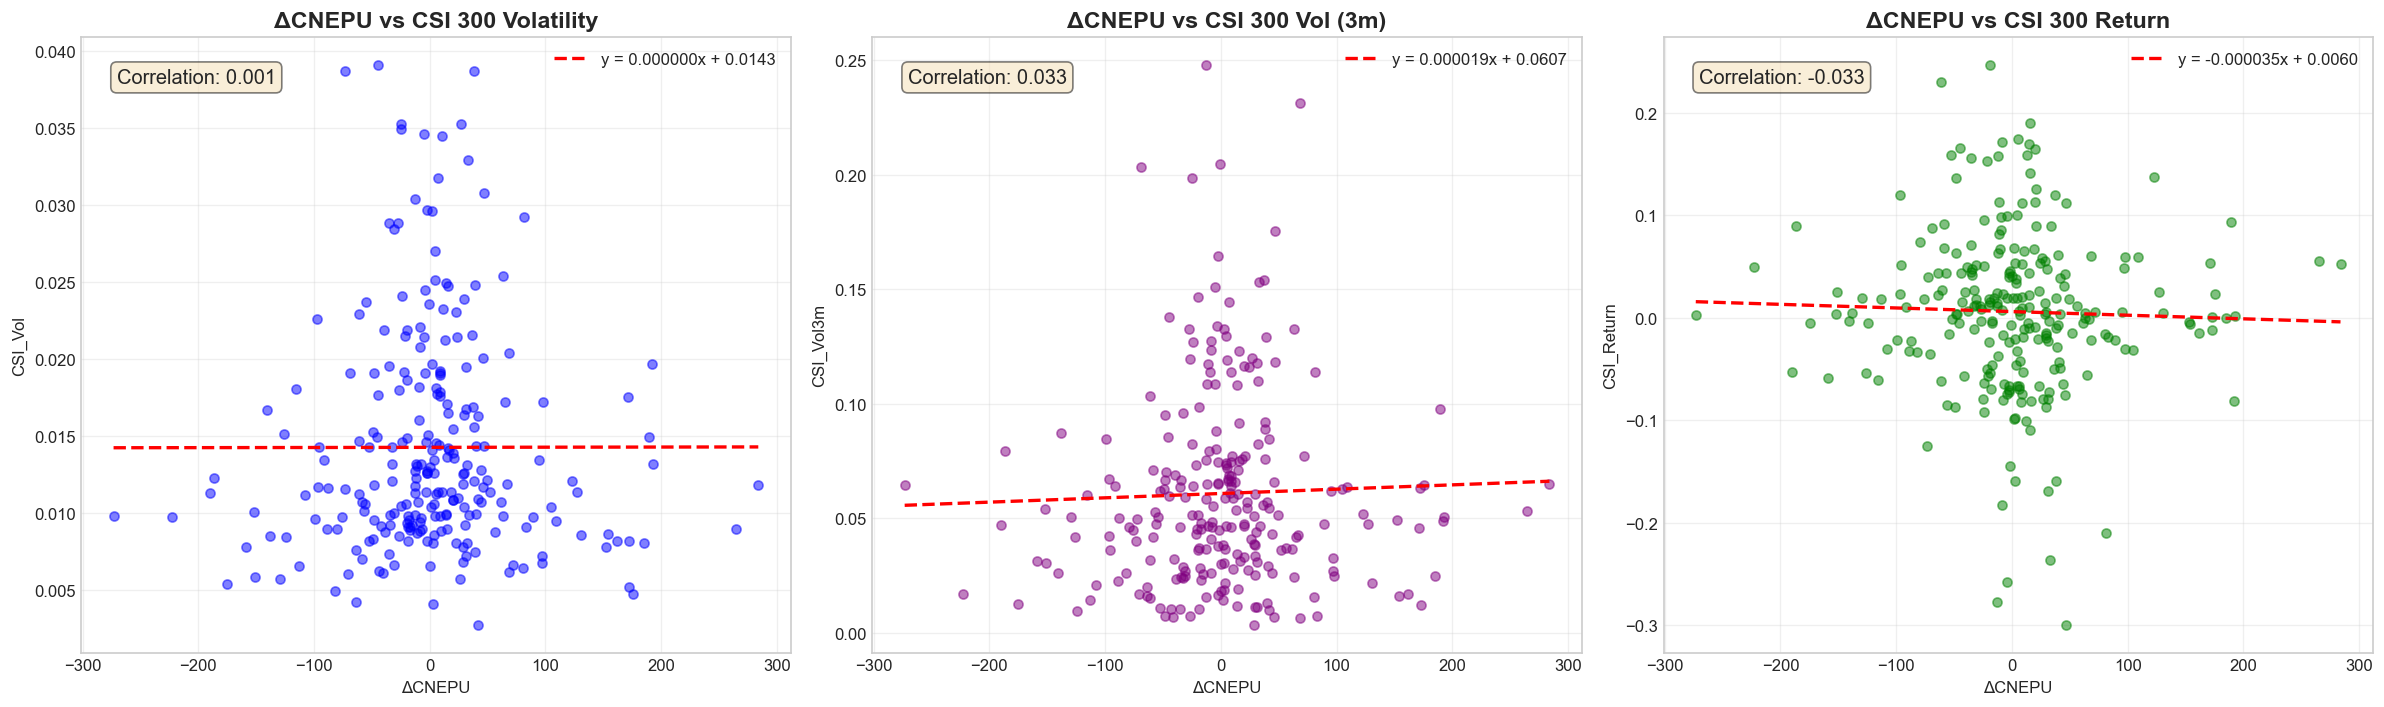

In [14]:
# Scatter plots: ΔCNEPU vs market variables
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (yvar, color, title) in enumerate(zip(y_vars, colors,
        ['ΔCNEPU vs CSI 300 Volatility', 'ΔCNEPU vs CSI 300 Vol (3m)', 'ΔCNEPU vs CSI 300 Return'])):
    data = df[['ΔCNEPU', yvar]].dropna()

    axes[i].scatter(data['ΔCNEPU'], data[yvar], alpha=0.5, s=30, color=color)

    z = np.polyfit(data['ΔCNEPU'], data[yvar], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['ΔCNEPU'].min(), data['ΔCNEPU'].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2,
                 label=f'y = {z[0]:.6f}x + {z[1]:.4f}')

    corr = data['ΔCNEPU'].corr(data[yvar])
    axes[i].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                 transform=axes[i].transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('ΔCNEPU')
    axes[i].set_ylabel(yvar)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Quantile Analysis

### 5.1 CNEPU Quintile Stratification

Mean Volatility by CNEPU Quintile:


,CSI_Vol,CSI_Vol3m,CSI_Vol6m
CNEPU_Quintile,,,
Q1 (Low),0.017115,0.066062,0.072383
Q2,0.016316,0.070014,0.081392
Q3,0.015486,0.076277,0.079237
Q4,0.011142,0.047916,0.049105
Q5 (High),0.011184,0.044057,0.049513


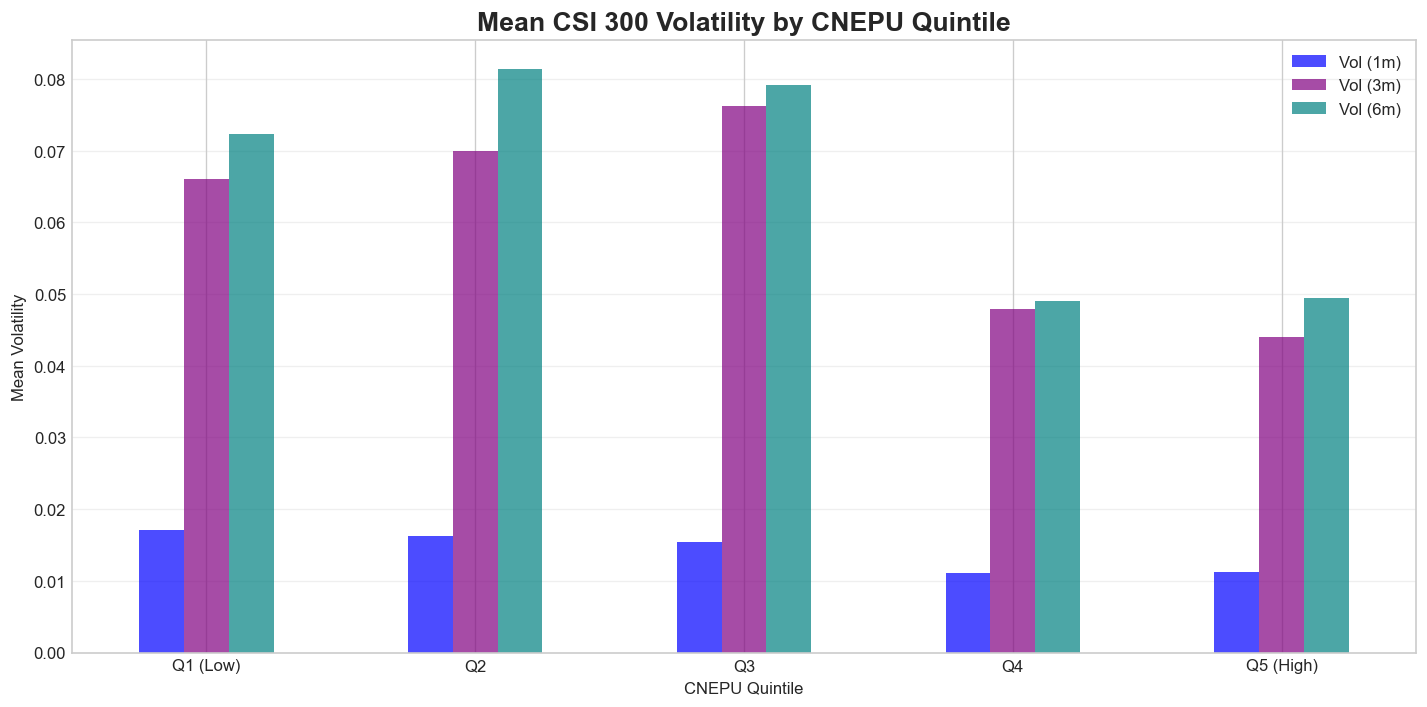

In [15]:
# Create CNEPU quintiles
df['CNEPU_Quintile'] = pd.qcut(df['CNEPU'], q=5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

# Calculate mean volatility by quintile
quintile_stats = df.groupby('CNEPU_Quintile')[['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']].mean()

print("Mean Volatility by CNEPU Quintile:")
display(quintile_stats)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
quintile_stats.plot(kind='bar', ax=ax, color=['blue', 'purple', 'teal'], alpha=0.7)
ax.set_title('Mean CSI 300 Volatility by CNEPU Quintile', fontsize=16, fontweight='bold')
ax.set_xlabel('CNEPU Quintile')
ax.set_ylabel('Mean Volatility')
ax.legend(['Vol (1m)', 'Vol (3m)', 'Vol (6m)'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.2 ΔCNEPU Quintile Stratification

Mean Volatility by ΔCNEPU Quintile:


,CSI_Vol,CSI_Vol3m,CSI_Vol6m
ΔCNEPU_Quintile,,,
Q1 (Large Decrease),0.012684,0.050877,0.057610
Q2,0.014653,0.061576,0.068712
Q3,0.015977,0.074370,0.075660
Q4,0.015961,0.064729,0.071846
Q5 (Large Increase),0.012041,0.052713,0.057304


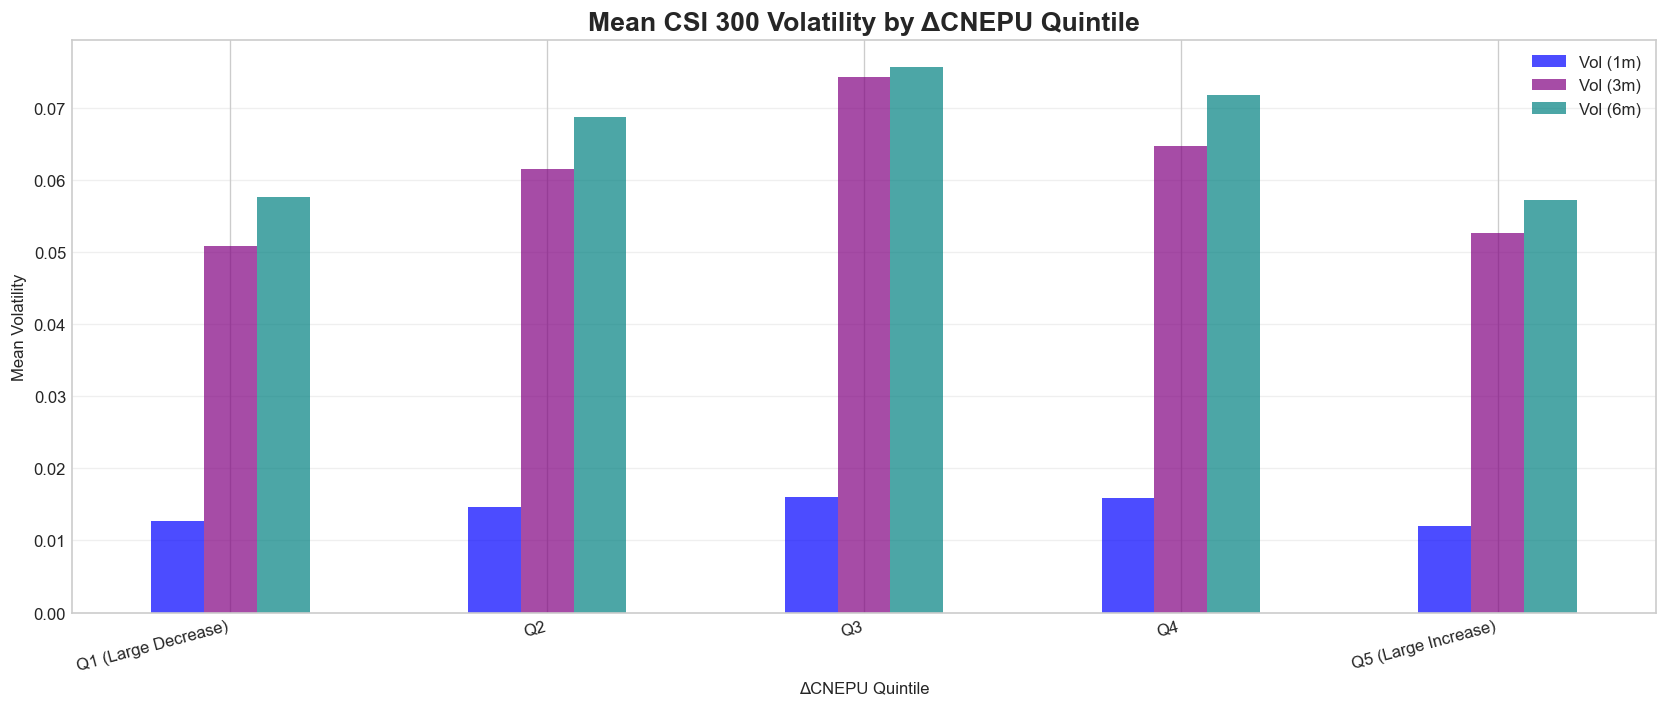

In [16]:
# Create ΔCNEPU quintiles
df_valid = df.dropna(subset=['ΔCNEPU']).copy()
df_valid['ΔCNEPU_Quintile'] = pd.qcut(df_valid['ΔCNEPU'], q=5,
                                       labels=['Q1 (Large Decrease)', 'Q2', 'Q3', 'Q4', 'Q5 (Large Increase)'])

# Calculate mean volatility by quintile
dcnepu_quintile_stats = df_valid.groupby('ΔCNEPU_Quintile')[['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']].mean()

print("Mean Volatility by ΔCNEPU Quintile:")
display(dcnepu_quintile_stats)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
dcnepu_quintile_stats.plot(kind='bar', ax=ax, color=['blue', 'purple', 'teal'], alpha=0.7)
ax.set_title('Mean CSI 300 Volatility by ΔCNEPU Quintile', fontsize=16, fontweight='bold')
ax.set_xlabel('ΔCNEPU Quintile')
ax.set_ylabel('Mean Volatility')
ax.legend(['Vol (1m)', 'Vol (3m)', 'Vol (6m)'])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Shock Analysis

Shock threshold (90th percentile): 128.30
Number of shock months: 25 (10.1%)

Mean Values: Shock vs Normal Periods:


,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Return
Normal,0.014734,0.062538,0.067932,0.005560
Shock,0.009928,0.045119,0.050568,0.009643


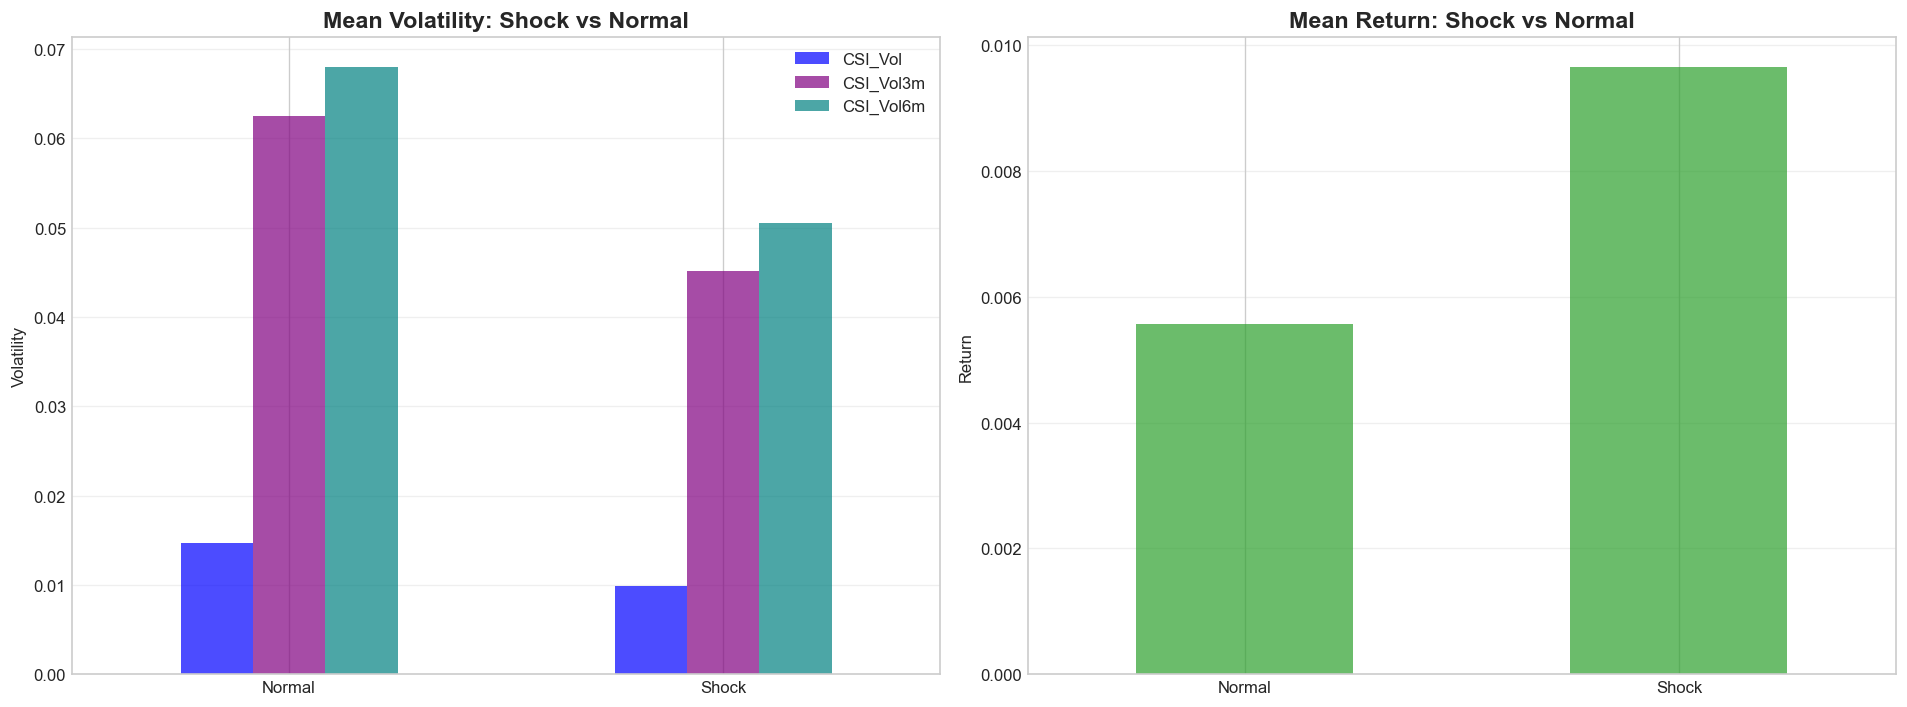

In [17]:
# Define shock periods (top 10% of ΔCNEPU absolute changes)
threshold = df['ΔCNEPU'].abs().quantile(0.90)
df['Is_Shock'] = df['ΔCNEPU'].abs() > threshold

print(f"Shock threshold (90th percentile): {threshold:.2f}")
print(f"Number of shock months: {df['Is_Shock'].sum()} ({df['Is_Shock'].sum() / len(df) * 100:.1f}%)")

# Compare volatility during shock vs normal periods
shock_comparison = df.groupby('Is_Shock')[['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m', 'CSI_Return']].mean()
shock_comparison.index = ['Normal', 'Shock']

print("\nMean Values: Shock vs Normal Periods:")
display(shock_comparison)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volatility comparison
shock_comparison[['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']].plot(kind='bar', ax=axes[0],
    color=['blue', 'purple', 'teal'], alpha=0.7)
axes[0].set_title('Mean Volatility: Shock vs Normal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Volatility')
axes[0].grid(True, alpha=0.3, axis='y')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Return comparison
ret_vals = shock_comparison['CSI_Return']
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in ret_vals]
ret_vals.plot(kind='bar', ax=axes[1], color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Mean Return: Shock vs Normal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3, axis='y')
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Lead-Lag Analysis

### 6.1 Lagged Correlations

Lagged Correlations (CNEPU_{t-lag} vs Target_t):


,CSI_Vol,CSI_Vol3m,CSI_Return
Lag (months),,,
0,-0.3214,-0.2448,-0.0434
1,-0.3246,-0.2647,-0.0238
2,-0.3150,-0.2889,-0.0388
3,-0.3164,-0.2996,-0.0513
4,-0.3290,-0.3022,-0.0461
5,-0.3553,-0.3354,-0.0628
6,-0.3374,-0.3070,-0.0545
7,-0.3235,-0.2914,-0.0631
8,-0.2996,-0.2664,-0.0350


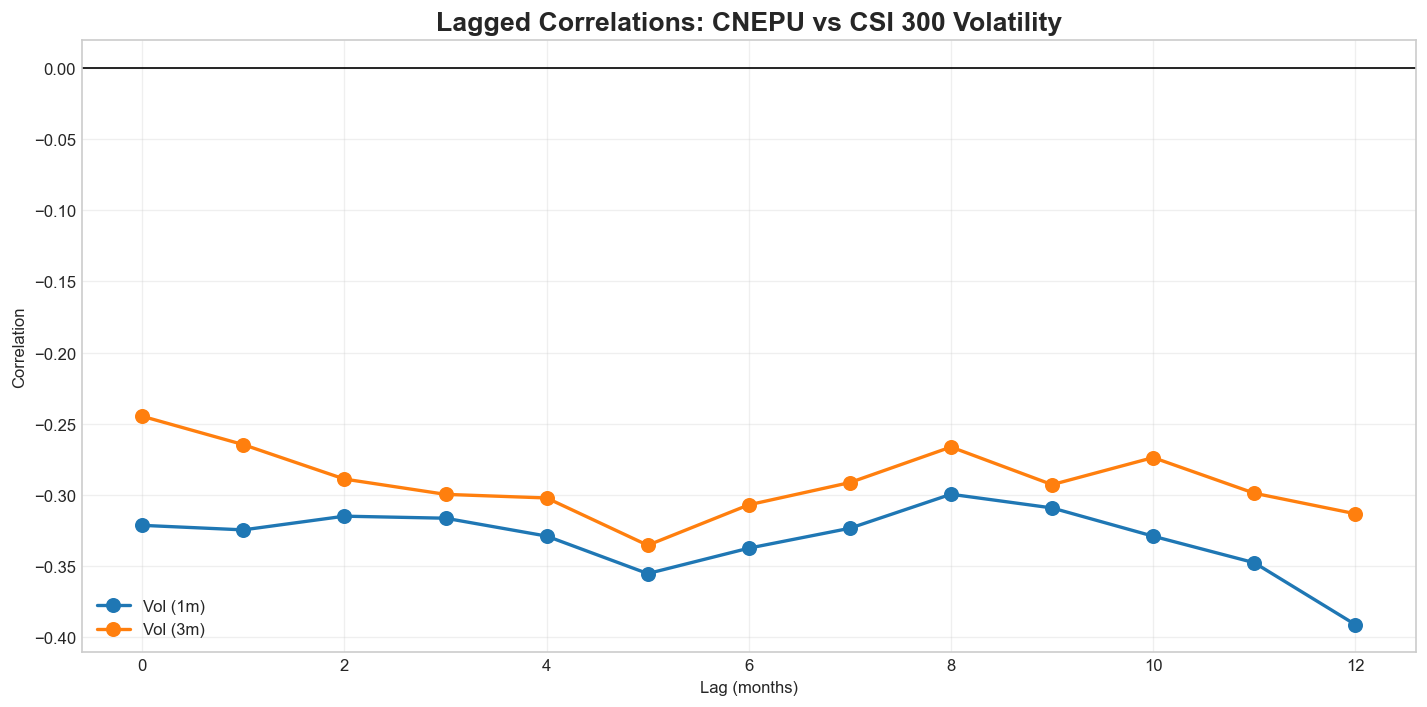

In [18]:
# Calculate lagged correlations (CNEPU lags 0-12 months vs current volatility)
max_lag = 12

# EPU level
lag_corrs = {}
for target in ['CSI_Vol', 'CSI_Vol3m', 'CSI_Return']:
    lag_corrs[target] = []
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = df['CNEPU'].corr(df[target])
        else:
            corr = df['CNEPU'].shift(lag).corr(df[target])
        lag_corrs[target].append(corr)

lag_corrs_df = pd.DataFrame(lag_corrs, index=range(max_lag + 1))
lag_corrs_df.index.name = 'Lag (months)'

print("Lagged Correlations (CNEPU_{t-lag} vs Target_t):")
display(lag_corrs_df.round(4))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
lag_corrs_df[['CSI_Vol', 'CSI_Vol3m']].plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('Lagged Correlations: CNEPU vs CSI 300 Volatility', fontsize=16, fontweight='bold')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation')
ax.legend(['Vol (1m)', 'Vol (3m)'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Lagged Correlations (ΔCNEPU_{t-lag} vs Target_t):


,CSI_Vol,CSI_Vol3m,CSI_Return
Lag (months),,,
0,0.0010,0.0329,-0.0329
1,-0.0143,0.0400,0.0322
2,-0.0089,0.0125,0.0099
3,0.0131,0.0007,-0.0115
4,0.0340,0.0473,0.0178
5,-0.0227,-0.0477,-0.0118
6,-0.0241,-0.0262,0.0144
7,-0.0438,-0.0523,-0.0432
8,0.0126,0.0372,0.0800


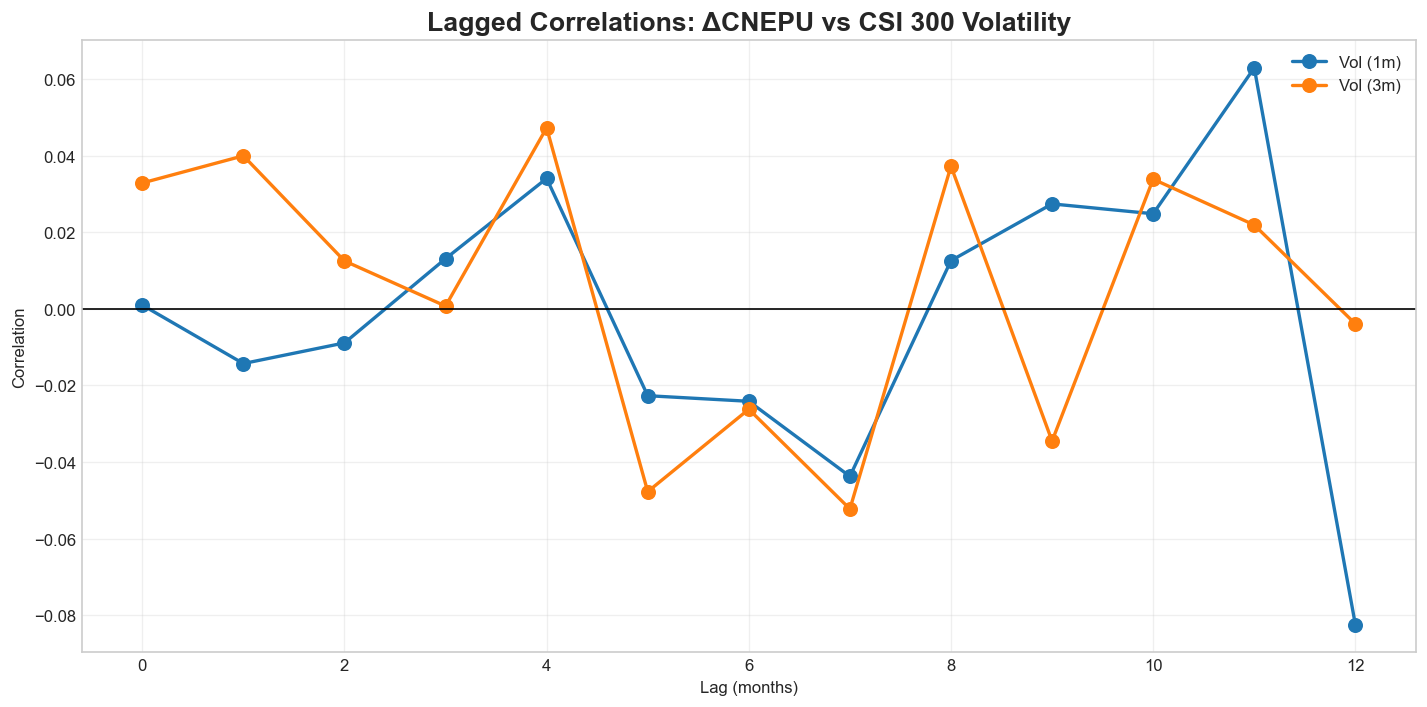

In [19]:
# ΔCNEPU lagged correlations
dcnepu_lag_corrs = {}
for target in ['CSI_Vol', 'CSI_Vol3m', 'CSI_Return']:
    dcnepu_lag_corrs[target] = []
    for lag in range(max_lag + 1):
        if lag == 0:
            corr = df['ΔCNEPU'].corr(df[target])
        else:
            corr = df['ΔCNEPU'].shift(lag).corr(df[target])
        dcnepu_lag_corrs[target].append(corr)

dcnepu_lag_corrs_df = pd.DataFrame(dcnepu_lag_corrs, index=range(max_lag + 1))
dcnepu_lag_corrs_df.index.name = 'Lag (months)'

print("Lagged Correlations (ΔCNEPU_{t-lag} vs Target_t):")
display(dcnepu_lag_corrs_df.round(4))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
dcnepu_lag_corrs_df[['CSI_Vol', 'CSI_Vol3m']].plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=8)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('Lagged Correlations: ΔCNEPU vs CSI 300 Volatility', fontsize=16, fontweight='bold')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Correlation')
ax.legend(['Vol (1m)', 'Vol (3m)'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Granger Causality Tests

In [20]:
# Granger causality test: Does CNEPU Granger-cause CSI 300 volatility?
print("=" * 80)
print("Granger Causality Test: CNEPU → CSI 300 Volatility")
print("=" * 80)

granger_data = df[['CNEPU', 'CSI_Vol']].dropna()

try:
    gc_result = grangercausalitytests(granger_data[['CSI_Vol', 'CNEPU']], maxlag=6, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: CNEPU → CSI 300 Volatility

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.7824  , p=0.0169  , df_denom=243, df_num=1
ssr based chi2 test:   chi2=5.8538  , p=0.0155  , df=1
likelihood ratio test: chi2=5.7853  , p=0.0162  , df=1
parameter F test:         F=5.7824  , p=0.0169  , df_denom=243, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.5751  , p=0.0782  , df_denom=240, df_num=2
ssr based chi2 test:   chi2=5.2576  , p=0.0722  , df=2
likelihood ratio test: chi2=5.2019  , p=0.0742  , df=2
parameter F test:         F=2.5751  , p=0.0782  , df_denom=240, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.7548  , p=0.1565  , df_denom=237, df_num=3
ssr based chi2 test:   chi2=5.4200  , p=0.1435  , df=3
likelihood ratio test: chi2=5.3607  , p=0.1472  , df=3
parameter F test:         F=1.7548  , p=0.1565  , df_denom=237, df_num=3

Granger Causality
number of lags (no zero)

In [21]:
# Granger causality test: Does CNEPU Granger-cause CSI 300 3m volatility?
print("=" * 80)
print("Granger Causality Test: CNEPU → CSI 300 Volatility (3m)")
print("=" * 80)

granger_data = df[['CNEPU', 'CSI_Vol3m']].dropna()

try:
    gc_result = grangercausalitytests(granger_data[['CSI_Vol3m', 'CNEPU']], maxlag=6, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: CNEPU → CSI 300 Volatility (3m)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.0802  , p=0.0251  , df_denom=240, df_num=1
ssr based chi2 test:   chi2=5.1437  , p=0.0233  , df=1
likelihood ratio test: chi2=5.0900  , p=0.0241  , df=1
parameter F test:         F=5.0802  , p=0.0251  , df_denom=240, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.8333  , p=0.0230  , df_denom=237, df_num=2
ssr based chi2 test:   chi2=7.8283  , p=0.0200  , df=2
likelihood ratio test: chi2=7.7044  , p=0.0212  , df=2
parameter F test:         F=3.8333  , p=0.0230  , df_denom=237, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.7264  , p=0.0449  , df_denom=234, df_num=3
ssr based chi2 test:   chi2=8.4239  , p=0.0380  , df=3
likelihood ratio test: chi2=8.2800  , p=0.0406  , df=3
parameter F test:         F=2.7264  , p=0.0449  , df_denom=234, df_num=3

Granger Causality
number of lags (no 

In [22]:
# Granger causality test: Does ΔCNEPU Granger-cause CSI 300 volatility?
print("=" * 80)
print("Granger Causality Test: ΔCNEPU → CSI 300 Volatility")
print("=" * 80)

granger_data = df[['ΔCNEPU', 'CSI_Vol']].dropna()

try:
    gc_result = grangercausalitytests(granger_data[['CSI_Vol', 'ΔCNEPU']], maxlag=6, verbose=True)
except Exception as e:
    print(f"Error: {e}")

Granger Causality Test: ΔCNEPU → CSI 300 Volatility

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1080  , p=0.7427  , df_denom=242, df_num=1
ssr based chi2 test:   chi2=0.1093  , p=0.7409  , df=1
likelihood ratio test: chi2=0.1093  , p=0.7409  , df=1
parameter F test:         F=0.1080  , p=0.7427  , df_denom=242, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1587  , p=0.8533  , df_denom=239, df_num=2
ssr based chi2 test:   chi2=0.3240  , p=0.8504  , df=2
likelihood ratio test: chi2=0.3238  , p=0.8505  , df=2
parameter F test:         F=0.1587  , p=0.8533  , df_denom=239, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1327  , p=0.9406  , df_denom=236, df_num=3
ssr based chi2 test:   chi2=0.4098  , p=0.9382  , df=3
likelihood ratio test: chi2=0.4094  , p=0.9383  , df=3
parameter F test:         F=0.1327  , p=0.9406  , df_denom=236, df_num=3

Granger Causality
number of lags (no zero

## 7. Key Findings Summary

In [23]:
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

print("\n1. DESCRIPTIVE STATISTICS")
print("-" * 80)
print(f"   - CNEPU Mean: {df['CNEPU'].mean():.2f}, Std: {df['CNEPU'].std():.2f}")
print(f"   - ΔCNEPU Mean: {df['ΔCNEPU'].mean():.2f}, Std: {df['ΔCNEPU'].std():.2f}")
print(f"   - CSI 300 Vol (1m) Mean: {df['CSI_Vol'].mean():.6f}")
print(f"   - CSI 300 Vol (3m) Mean: {df['CSI_Vol3m'].mean():.6f}")
print(f"   - CSI 300 Return Mean: {df['CSI_Return'].mean():.6f}")

print("\n2. STATIC CORRELATIONS")
print("-" * 80)
print(f"   - CNEPU vs CSI Vol: {df['CNEPU'].corr(df['CSI_Vol']):.3f}")
print(f"   - CNEPU vs CSI Vol3m: {df['CNEPU'].corr(df['CSI_Vol3m']):.3f}")
print(f"   - CNEPU vs CSI Vol6m: {df['CNEPU'].corr(df['CSI_Vol6m']):.3f}")
print(f"   - ΔCNEPU vs CSI Vol: {df['ΔCNEPU'].corr(df['CSI_Vol']):.3f}")
print(f"   - CNEPU vs CSI Return: {df['CNEPU'].corr(df['CSI_Return']):.3f}")

print("\n3. ROLLING CORRELATIONS (12-month)")
print("-" * 80)
print(f"   - CNEPU vs CSI Vol Mean: {df['CNEPU_Vol_Corr12m'].mean():.3f}")
print(f"   - CNEPU vs CSI Vol3m Mean: {df['CNEPU_Vol3m_Corr12m'].mean():.3f}")
print(f"   - CNEPU vs CSI Return Mean: {df['CNEPU_Ret_Corr12m'].mean():.3f}")

print("\n4. QUANTILE ANALYSIS")
print("-" * 80)
print("   CNEPU Quintile Volatility Differences:")
print(f"   - CSI Vol: Q5/Q1 ratio = {quintile_stats.loc['Q5 (High)', 'CSI_Vol'] / quintile_stats.loc['Q1 (Low)', 'CSI_Vol']:.2f}x")
print(f"   - CSI Vol3m: Q5/Q1 ratio = {quintile_stats.loc['Q5 (High)', 'CSI_Vol3m'] / quintile_stats.loc['Q1 (Low)', 'CSI_Vol3m']:.2f}x")

print("\n5. SHOCK ANALYSIS")
print("-" * 80)
shock_comparison_2 = df.groupby('Is_Shock')[['CSI_Vol', 'CSI_Vol3m']].mean()
shock_comparison_2.index = ['Normal', 'Shock']
print(f"   - Shock months: {df['Is_Shock'].sum()} ({df['Is_Shock'].sum() / len(df) * 100:.1f}%)")
print(f"   - CSI Vol: Shock/Normal ratio = {shock_comparison_2.loc['Shock', 'CSI_Vol'] / shock_comparison_2.loc['Normal', 'CSI_Vol']:.2f}x")
print(f"   - CSI Vol3m: Shock/Normal ratio = {shock_comparison_2.loc['Shock', 'CSI_Vol3m'] / shock_comparison_2.loc['Normal', 'CSI_Vol3m']:.2f}x")

print("\n6. LEAD-LAG ANALYSIS")
print("-" * 80)
print("   Strongest lagged correlations (CNEPU → CSI Vol):")
max_corr_idx = lag_corrs_df['CSI_Vol'].abs().idxmax()
max_corr = lag_corrs_df.loc[max_corr_idx, 'CSI_Vol']
print(f"   - Best lag: {max_corr_idx} months, Corr = {max_corr:.3f}")
max_corr_idx3 = lag_corrs_df['CSI_Vol3m'].abs().idxmax()
max_corr3 = lag_corrs_df.loc[max_corr_idx3, 'CSI_Vol3m']
print(f"   - Best lag (3m vol): {max_corr_idx3} months, Corr = {max_corr3:.3f}")

print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR MODELING")
print("=" * 80)
print("\n1. FEATURE SELECTION:")
print("   - Include CNEPU level and ΔCNEPU as primary features")
print("   - Consider lagged CNEPU values (1-3 months) based on correlation analysis")
print("   - CNEPU_MA12 and CNEPU_Std12 may capture regime changes")

print("\n2. TARGET SELECTION:")
print("   - CSI_Vol3m may be preferable to CSI_Vol for smoother signal")
print("   - Compare model performance across different volatility horizons")

print("\n3. MODEL COMPLEXITY:")
print("   - Quantile analysis suggests potential non-linear relationships")
print("   - Consider quantile regression or regime-switching models")
print("   - Rolling correlations show time-varying relationships")

print("\n4. TEMPORAL DYNAMICS:")
print("   - Lead-lag analysis shows whether CNEPU has predictive power")
print("   - Granger causality tests provide formal evidence")
print("   - Consider time-series models (VAR, GARCH) or lagged features")

print("\n" + "=" * 80)

KEY FINDINGS SUMMARY

1. DESCRIPTIVE STATISTICS
--------------------------------------------------------------------------------
   - CNEPU Mean: 182.10, Std: 123.94
   - ΔCNEPU Mean: 1.21, Std: 73.89
   - CSI 300 Vol (1m) Mean: 0.014248
   - CSI 300 Vol (3m) Mean: 0.060754
   - CSI 300 Return Mean: 0.005975

2. STATIC CORRELATIONS
--------------------------------------------------------------------------------
   - CNEPU vs CSI Vol: -0.321
   - CNEPU vs CSI Vol3m: -0.245
   - CNEPU vs CSI Vol6m: -0.323
   - ΔCNEPU vs CSI Vol: 0.001
   - CNEPU vs CSI Return: -0.043

3. ROLLING CORRELATIONS (12-month)
--------------------------------------------------------------------------------
   - CNEPU vs CSI Vol Mean: -0.090
   - CNEPU vs CSI Vol3m Mean: 0.096
   - CNEPU vs CSI Return Mean: 0.021

4. QUANTILE ANALYSIS
--------------------------------------------------------------------------------
   CNEPU Quintile Volatility Differences:
   - CSI Vol: Q5/Q1 ratio = 0.65x
   - CSI Vol3m: Q5/Q1 ra